<a href="https://colab.research.google.com/github/tirthas970-cmyk/PICASO/blob/main/PICASO_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PICASO**


---

**P**hysics-**I**nformed **C**ross-**A**ttention **S**olar **O**ptimizer

We present the applied specializations of:
*   Knowledge-Informed Machine Leanring Model
*   Neural Networks
*   AI Explainability


**Goal**: Predict M and X-class solar flares through physically informed and explainable CNN


> This notebook includes our major code, which are processing the data, model architecture, training, evalutation, and model explainability. The code for our data acquisition is not included in order to make the notebook concise and focused on the integral parts of this project. Nonetheless, feel free to contact us if you want to see the code for data acquisition.



> Additionally, this is our final **preliminary** model for the summer. We plan to advance this model over the next few months.






In [ ]:
#Dependencies

!pip install sunpy[all] drms
!pip install huggingface_hub
!pip install webdataset -q

from huggingface_hub import snapshot_download
from google.colab import userdata
import os
import pandas as pd
import requests
import io
import tarfile
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import math
from google.colab import drive
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import random
import cv2
import sunpy.visualization.colormaps
import shap



### 1. Data Processing



> Note: This does not include **all** our data processing such as padding or Cylindrical Equal Area remapping as those are intertwined with our data acquisition scripts.




In [ ]:
# You need to have a hugging face token as a Google Colab Secret in order to run this script
# This script downloads dataset in the format of .tar shards from Hugging Face that we collected

print("Beginning filtered download of v2 .tar shards from Hugging Face Hub...")
print("This process may take some time depending on your network speed and the size of the files.")

try:
    local_data_path = snapshot_download(
        repo_id="X-FlareNet/solar-flare-magnetogram-shards",
        repo_type="dataset",
        token=userdata.get("hf_token"),
        local_dir="/content/local_solar_shards",
        allow_patterns=["*v2*.tar"]
    )
    print(f"\n[SUCCESS] v2 shards downloaded locally at: {local_data_path}")
    print("Checking remaining disk space:")
    os.system("df -h /content")
    print(f"\nListing contents of the download directory: {local_data_path}")
    os.system(f"ls -l {local_data_path}")
except Exception as e:
    print(f"\n[ERROR] Filtered download failed: {e}")
finally:
    print("\nFile download process concluded.")

Beginning filtered download of v2 .tar shards from Hugging Face Hub...
This process may take some time depending on your network speed and the size of the files.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 339 files:   0%|          | 0/339 [00:00<?, ?it/s]


[SUCCESS] v2 shards downloaded locally at: /content/local_solar_shards
Checking remaining disk space:

Listing contents of the download directory: /content/local_solar_shards

File download process concluded.


In [ ]:
# This script gets our tabular dataset & AR splits from drive.

HF_TOKEN = userdata.get("hf_token")
HF_REPO = "X-FlareNet/solar-flare-magnetogram-shards"
headers = {"Authorization": f"Bearer {HF_TOKEN}"} if HF_TOKEN else {}

def read_txt_from_hf(file_name):
    url = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/{file_name}"
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return set(int(line.strip()) for line in response.text.split('\n') if line.strip())
    else:
        raise FileNotFoundError(f"Could not load {file_name} from Hugging Face. Status code: {response.status_code}")

print("--- Fetching Locked Split Parameters from Hugging Face ---")
train_set = read_txt_from_hf("train_ars.txt")
val_set = read_txt_from_hf("val_ars.txt")
test_set = read_txt_from_hf("test_ars.txt")
print(f"[SUCCESS] Loaded {len(train_set)} train, {len(val_set)} val, and {len(test_set)} test regions!")

print("\n--- Downloading Tabular Feature Matrix to Local Colab Folder ---")
csv_filename = "solar_flare_61k_aligned_metadata_cleaned.csv"
csv_url = f"https://huggingface.co/datasets/{HF_REPO}/resolve/main/{csv_filename}"

# Download the file to the local Colab folder
response_csv = requests.get(csv_url, headers=headers, stream=True)

if response_csv.status_code == 200:
    # Save the raw data directly to Colab's file storage
    with open(csv_filename, "wb") as f:
        f.write(response_csv.content)
    print(f"[SUCCESS] Download complete! Saved to local folder as: {csv_filename}")

    master_df = pd.read_csv(csv_filename)
    print(f"Master dataset loaded from local path! Shape: {master_df.shape}")
else:
    print(f"[ERROR] Failed to download CSV file. Status code: {response_csv.status_code}")
    master_df = pd.DataFrame()

master_df.head()


--- Fetching Locked Split Parameters from Hugging Face ---
[SUCCESS] Loaded 716 train, 122 val, and 107 test regions!

--- Downloading Tabular Feature Matrix to Local Colab Folder ---
[SUCCESS] Download complete! Saved to local folder as: solar_flare_61k_aligned_metadata_cleaned.csv
Master dataset loaded from local path! Shape: (60785, 16)


,shard_file,key,noaa_id,year,timestamp,label,NOAA_AR,USFLUX,TOTUSJH,TOTPOT,MEANSHR,MEANJZH,R_VALUE,AREA_ACR,SHRGT45,MEANPOT
0,shard_2012_ch1_000000-v2.tar,AR11383_20120101_000000,11383,2012,2012-01-01 00:00:00,0,11383.0,7.027317e+21,224.268,8.045968e+22,31.449,-0.003098,4.535,548.572998,25.729,4697.9770
1,shard_2012_ch1_000000-v2.tar,AR11383_20120101_040000,11383,2012,2012-01-01 04:00:00,0,11383.0,4.089614e+21,82.626,6.685352e+21,17.000,-0.002021,4.206,315.192474,4.490,745.9964
2,shard_2012_ch1_000000-v2.tar,AR11383_20120101_080000,11383,2012,2012-01-01 08:00:00,0,11383.0,2.088589e+21,41.927,4.184683e+21,16.812,-0.001421,4.531,90.980270,4.091,920.8098
3,shard_2012_ch1_000000-v2.tar,AR11386_20120101_000000,11386,2012,2012-01-01 00:00:00,0,11386.0,6.019818e+21,407.243,9.172299e+22,35.367,0.004414,3.537,341.861847,29.022,7401.8040
4,shard_2012_ch1_000000-v2.tar,AR11386_20120101_040000,11386,2012,2012-01-01 04:00:00,0,11386.0,6.204937e+21,400.439,9.008860e+22,34.008,0.004790,3.300,334.617218,27.060,7014.3270


In [ ]:
# This script processes our data in order to make it fully compatible with our CNN through features like scaling, normalization, etc.

class SuperFastSolarDataset(Dataset):
    def __init__(self, local_dir, allowed_ar_set, csv_path, tabular_mean=None, tabular_std=None):
        print(f"Loading master tabular data from {csv_path}...")
        self.df = pd.read_csv(csv_path)
        self.df.set_index('key', inplace=True)
        self.allowed_ar_set = allowed_ar_set

        # Store scaling parameters (if provided)
        self.tabular_mean = tabular_mean
        self.tabular_std = tabular_std

        self.samples = []

        self.tar_files = sorted(glob.glob(os.path.join(local_dir, "**", "*.tar"), recursive=True))
        print(f"Indexing local files... Parsing headers from {len(self.tar_files)} shards.")

        for tar_path in self.tar_files:
            with tarfile.open(tar_path, "r") as tar:
                for member in tar.getmembers():
                    if member.isfile() and member.name.endswith('.npy'):
                        filename = member.name
                        base_key = filename.replace(".npy", "")
                        try:
                            first_part = base_key.split("_")[0]
                            ar_num = int(first_part.replace("AR", ""))

                            if ar_num in self.allowed_ar_set and base_key in self.df.index:
                                self.samples.append((tar_path, member, base_key))
                        except Exception:
                            continue

        print(f"Index complete! Found {len(self.samples)} valid frames.")
        self.labels = [int(self.df.loc[base_key]['label']) for _, _, base_key in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        tar_path, tar_member, base_key = self.samples[idx]

        with tarfile.open(tar_path, "r") as tar:
            img_bytes = tar.extractfile(tar_member).read()

        img = np.load(io.BytesIO(img_bytes)).astype(np.float32)

        # Image data normalization
        solar_mask = (img != 0.0)
        norm_pixels = np.zeros_like(img, dtype=np.float32)
        clipped = np.clip(img[solar_mask], -4000.0, 4000.0)
        norm_pixels[solar_mask] = (clipped + 4000.0) / 8000.0
        img_3ch = np.repeat(norm_pixels[np.newaxis, :, :], 3, axis=0)
        img_tensor = torch.tensor(img_3ch, dtype=torch.float32)

        # Pull tabular features and labels
        csv_row = self.df.loc[base_key]
        tabular_features = csv_row.iloc[-9:].values.astype(np.float32)
        label_val = int(csv_row['label'])

        label_tensor = torch.tensor(label_val, dtype=torch.long)
        tabular_tensor = torch.tensor(tabular_features, dtype=torch.float32)
        tabular_tensor = torch.nan_to_num(tabular_tensor, nan=0.0, posinf=0.0, neginf=0.0)

        if self.tabular_mean is not None and self.tabular_std is not None:
            tabular_tensor = (tabular_tensor - self.tabular_mean) / (self.tabular_std + 1e-8)

        return img_tensor, tabular_tensor, label_tensor

In [ ]:
# This cell creates our dataloaders

print("Calculating training set mean and std for tabular features...")
master_df.set_index('key', inplace=True)

train_tabular_values = []
for base_key, row in master_df.iterrows():
    try:
        first_part = base_key.split("_")[0]
        ar_num = int(first_part.replace("AR", ""))
        if ar_num in train_set:
            train_tabular_values.append(row.iloc[-9:].values.astype(np.float32))
    except Exception:
        continue

# Convert to a NumPy array and compute statistics
train_tabular_array = np.array(train_tabular_values)
train_mean = torch.tensor(np.nanmean(train_tabular_array, axis=0), dtype=torch.float32)
train_std = torch.tensor(np.nanstd(train_tabular_array, axis=0), dtype=torch.float32)

print("Training Tabular Mean computed successfully.")

train_dataset = SuperFastSolarDataset(
    local_dir="/content/local_solar_shards",
    allowed_ar_set=train_set,
    csv_path=csv_filename,
    tabular_mean=train_mean,
    tabular_std=train_std
)

val_dataset = SuperFastSolarDataset(
    local_dir="/content/local_solar_shards",
    allowed_ar_set=val_set,
    csv_path=csv_filename,
    tabular_mean=train_mean,
    tabular_std=train_std
)

test_dataset = SuperFastSolarDataset(
    local_dir="/content/local_solar_shards",
    allowed_ar_set=test_set,
    csv_path=csv_filename,
    tabular_mean=train_mean,
    tabular_std=train_std
)

class_counts = np.bincount(train_dataset.labels)
print("Training set class distribution [Quiet, M-Class, X-Class]:", class_counts)

beta = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
class_weights = (1.0 - beta) / effective_num
class_weights = class_weights / np.sum(class_weights) * len(class_counts)
print("Computed Class Weights:", class_weights)

sample_weights = [class_weights[label] for label in train_dataset.labels]

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=train_sampler,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("Train, Validation, and Test DataLoaders initialized successfully!")

Calculating training set mean and std for tabular features...


/usr/local/lib/python3.13/dist-packages/numpy/lib/_nanfunctions_impl.py:1904: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)


Training Tabular Mean computed successfully.
Loading master tabular data from solar_flare_61k_aligned_metadata_cleaned.csv...
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 46297 valid frames.
Loading master tabular data from solar_flare_61k_aligned_metadata_cleaned.csv...
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 8429 valid frames.
Loading master tabular data from solar_flare_61k_aligned_metadata_cleaned.csv...
Indexing local files... Parsing headers from 339 shards.
Index complete! Found 7220 valid frames.
Training set class distribution [Quiet, M-Class, X-Class]: [44472  1631   194]
Computed Class Weights: [0.0508451  0.33388397 2.61527093]
Train, Validation, and Test DataLoaders initialized successfully!


In [ ]:
# This class applies our hierarchical focal loss and inverse log weights

class V4BalancedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        if alpha is not None:
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        p_t = torch.exp(-ce_loss)
        focal_weight = (1.0 - p_t) ** self.gamma
        loss = focal_weight * ce_loss

        if self.alpha is not None:
            at = self.alpha[targets]
            loss = at * loss

        return loss.mean()


#  Calculate Weights for the Binary Head
quiet_count = 44472
total_flares = 1631 + 194
binary_counts = np.array([quiet_count, total_flares], dtype=np.float32)
binary_inv_freq = binary_counts.sum() / binary_counts
binary_log_weights = np.log(binary_inv_freq) + 1.0
binary_weights_tensor = torch.tensor(binary_log_weights / binary_log_weights[0], dtype=torch.float32).cuda()


# Calculate Weights for the Severity Head (M-Class vs. X-Class)
severity_counts = np.array([1631, 194], dtype=np.float32)
severity_inv_freq = severity_counts.sum() / severity_counts
severity_log_weights = np.log(severity_inv_freq) + 1.0
severity_weights_tensor = torch.tensor(severity_log_weights / severity_log_weights[0], dtype=torch.float32).cuda()


# Hierarchical Wrapper
class HierarchicalV4FocalLoss(nn.Module):
    def __init__(self, binary_alpha, severity_alpha, gamma=2.0):
        super().__init__()
        self.binary_focal = V4BalancedFocalLoss(alpha=binary_alpha, gamma=gamma)
        self.severity_focal = V4BalancedFocalLoss(alpha=severity_alpha, gamma=gamma)

    def forward(self, binary_logits, severity_logits, targets):
        binary_targets = (targets > 0).long()
        loss_binary = self.binary_focal(binary_logits, binary_targets)

        severity_mask = (targets > 0)

        if severity_mask.sum() > 0:
            severity_targets = torch.clamp(targets[severity_mask] - 1, min=0)
            loss_severity = self.severity_focal(severity_logits[severity_mask], severity_targets)
        else:
            loss_severity = torch.tensor(0.0, device=binary_logits.device)

        return loss_binary + loss_severity


criterion = HierarchicalV4FocalLoss(
    binary_alpha=binary_weights_tensor,
    severity_alpha=severity_weights_tensor,
    gamma=2.0
)

### 2. Model Architecture, Training, Validation, and Testing

In [ ]:
# This is our model architecure with our Cross-Attention mechanism

# Classs to inject 2D positional encoding in order to preversive spatial features in magnetogram
class Verified2DPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_h=50, max_w=50):
        super().__init__()
        self.d_model = d_model
        assert d_model % 4 == 0, "Embed dim must be divisible by 4 for balanced 2D encoding"

        pe = torch.zeros(max_h, max_w, d_model)
        d_per_axis = d_model // 2  # 256 channels for H, 256 channels for W

        div_term = torch.exp(torch.arange(0, d_per_axis, 2).float() * (-math.log(10000.0) / d_per_axis))

        pos_h = torch.arange(0, max_h).unsqueeze(1).float()
        pos_w = torch.arange(0, max_w).unsqueeze(1).float()

        sin_h = torch.sin(pos_h * div_term)
        cos_h = torch.cos(pos_h * div_term)
        sin_w = torch.sin(pos_w * div_term)
        cos_w = torch.cos(pos_w * div_term)

        pe_h = torch.zeros(max_h, max_w, d_per_axis)
        pe_h[:, :, 0::2] = sin_h.unsqueeze(1).repeat(1, max_w, 1)
        pe_h[:, :, 1::2] = cos_h.unsqueeze(1).repeat(1, max_w, 1)

        pe_w = torch.zeros(max_h, max_w, d_per_axis)
        pe_w[:, :, 0::2] = sin_w.unsqueeze(0).repeat(max_h, 1, 1)
        pe_w[:, :, 1::2] = cos_w.unsqueeze(0).repeat(max_h, 1, 1)

        pe = torch.cat([pe_h, pe_w], dim=-1)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x, h, w):
        pe_sliced = self.pe[:, :h, :w, :].reshape(1, h * w, self.d_model)
        return x + pe_sliced


class SolarCrossAttention(nn.Module):
    def __init__(self, tabular_dim=9, embed_dim=512, num_heads=8):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Inject the 2D Positional Encoding
        self.pos_encoder = Verified2DPositionalEncoding(d_model=embed_dim)

        self.tabular_dim = tabular_dim
        self.embed_dim = embed_dim

        # Disentangled Physical Embedders
        self.param_embedders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, 64),
                nn.SiLU(),
                nn.Linear(64, embed_dim)
            ) for _ in range(tabular_dim)
        ])
        self.tab_norm = nn.LayerNorm(embed_dim)

        # Attention Engine (Tabular = Query, Spatial = Key/Value)
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            batch_first=True
        )
        self.fusion_norm = nn.LayerNorm(embed_dim)

        # Token Interaction Layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=512,
            batch_first=True,
            dropout=0.1
        )
        self.token_aggregator = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # Head 1: (Quiet vs. Flare) -> Binary Output (2 classes)
        self.binary_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

        # Head 2: Severity Grader (M-Class vs. X-Class) -> Binary Output (2 classes)
        self.severity_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.SiLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, images, tabular_data):
        B = images.size(0)

        # Backbone Spatial Extraction -> (B, 512, H', W')
        spatial_features = self.backbone(images)
        _, C, H_prime, W_prime = spatial_features.shape

        # Flatten image spatially -> (B, H'*W', embed_dim) and add positional encoding
        spatial_flat = spatial_features.view(B, C, -1).permute(0, 2, 1)
        spatial_positioned = self.pos_encoder(spatial_flat, H_prime, W_prime)

        tab_tokens = []
        for i in range(self.tabular_dim):
            param_val = tabular_data[:, i:i+1]
            param_token = self.param_embedders[i](param_val)
            tab_tokens.append(param_token.unsqueeze(1))

        query_tab = torch.cat(tab_tokens, dim=1)
        query_tab = self.tab_norm(query_tab)

        # Cross Attention Execution
        attn_output, attn_weights = self.cross_attention(
            query=query_tab,
            key=spatial_positioned,
            value=spatial_flat
        )

        # Residual Fusion and Normalization
        fused_tokens = self.fusion_norm(attn_output + query_tab)

        # Token Interaction
        fused_tokens = self.token_aggregator(fused_tokens)

        # Global Average Pool over tokens to produce class vector -> (B, embed_dim)
        fused_pooled = fused_tokens.mean(dim=1)

        binary_logits = self.binary_head(fused_pooled)
        severity_logits = self.severity_head(fused_pooled)

        return binary_logits, severity_logits, attn_weights

In [ ]:
drive.mount("/content/drive")

In [ ]:
# This scritp defines our training loop

def train_fusion_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=5, start_epoch=0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"Starting Cross-Attention Fusion training loop on local high-speed NVMe data using: {device}...")
    print(f"Training will run from Epoch {start_epoch + 1} to Epoch {start_epoch + num_epochs}\n")

    for epoch in range(start_epoch, start_epoch + num_epochs):
        model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0
        train_batches = 0

        for batch_idx, (images, tabular_data, labels) in enumerate(train_loader):
            images = images.to(device)
            tabular_data = tabular_data.to(device).float()
            labels = labels.to(device).long()

            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            optimizer.zero_grad()

            binary_logits, severity_logits, _ = model(images, tabular_data)

            loss = criterion(binary_logits, severity_logits, labels)

            loss.backward()

            # Protects pre-trained ResNet backbone weights from rare-class gradient spikes
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            running_train_loss += loss.item()

            # Reconstructs 3-Class probs for acc tracking
            p_binary = torch.softmax(binary_logits, dim=-1)
            p_severity = torch.softmax(severity_logits, dim=-1)
            joint_probs = torch.cat([
                p_binary[:, 0:1],
                p_binary[:, 1:2] * p_severity[:, 0:1],
                p_binary[:, 1:2] * p_severity[:, 1:2]
            ], dim=-1)

            _, predicted = torch.max(joint_probs.data, 1)

            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            train_batches += 1

            if batch_idx % 50 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f"Epoch [{epoch+1}/{start_epoch + num_epochs}] | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f} | LR: {current_lr:.6f}")

        epoch_train_loss = running_train_loss / train_batches if train_batches > 0 else 0.0
        train_acc = (correct_train / total_train) * 100 if total_train > 0 else 0.0

        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        val_batches = 0

        with torch.no_grad():
            for images, tabular_data, labels in val_loader:
                images = images.to(device)
                tabular_data = tabular_data.to(device).float()
                labels = labels.to(device).long()

                if images.shape[1] == 1:
                    images = images.repeat(1, 3, 1, 1)

                binary_logits, severity_logits, _ = model(images, tabular_data)
                loss = criterion(binary_logits, severity_logits, labels)
                running_val_loss += loss.item()

                p_binary = torch.softmax(binary_logits, dim=-1)
                p_severity = torch.softmax(severity_logits, dim=-1)
                joint_probs = torch.cat([
                    p_binary[:, 0:1],
                    p_binary[:, 1:2] * p_severity[:, 0:1],
                    p_binary[:, 1:2] * p_severity[:, 1:2]
                ], dim=-1)

                _, predicted = torch.max(joint_probs.data, 1)

                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                val_batches += 1

        epoch_val_loss = running_val_loss / val_batches if val_batches > 0 else 0.0
        val_acc = (correct_val / total_val) * 100 if total_val > 0 else 0.0

        print(f"\n>>> Epoch [{epoch+1}/{start_epoch + num_epochs}] COMPLETE <<<")
        print(f"Loss: {epoch_train_loss:.4f} | Acc: {train_acc:.2f}%")
        print(f"Val_Loss: {epoch_val_loss:.4f} | Val_Acc: {val_acc:.2f}%\n")

        torch.save(model.state_dict(), f"/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/cross_attn_fusion_epochV4_hybrid5_{epoch+1}.pth")

        # Checkpoitnt
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'train_loss': epoch_train_loss,
            'val_loss': epoch_val_loss
        }
        torch.save(checkpoint, f"/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid5_{epoch+1}.pt")
        print(f"Resumable checkpoint and weights saved safely for Epoch {epoch+1}!\n")

    print("Training phase finished!")

In [ ]:
# This cell defines our optimizers, and the executes the training
tabular_dim = 9
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8).to(device)

binary_w = torch.tensor([1.0, 5.0], device=device)
severity_w = torch.tensor([1.0, 10.0], device=device)

optimizer = AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-6},          # Backbone feature protection
    {'params': model.cross_attention.parameters(), 'lr': 5e-5},  # Attention engine
    {'params': model.param_embedders.parameters(), 'lr': 5e-5},    # Tabular embedders (Crucial!)
    {'params': model.token_aggregator.parameters(), 'lr': 5e-5}, # Token aggregator (Crucial!)
    {'params': model.tab_norm.parameters(), 'lr': 5e-5},         # Tabular LayerNorm
    {'params': model.fusion_norm.parameters(), 'lr': 5e-5},        # Fusion LayerNorm
    {'params': model.binary_head.parameters(), 'lr': 5e-5},      # Gatekeeper head
    {'params': model.severity_head.parameters(), 'lr': 5e-5}     # Grader head
], weight_decay=1e-2)

epochs = 8
total_steps = epochs * len(train_loader)

def get_lr_lambda(current_step, num_warmup_steps, num_training_steps):
    if current_step < num_warmup_steps:
        return float(current_step) / float(max(1, num_warmup_steps))
    progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = LambdaLR(optimizer, lr_lambda=lambda step: get_lr_lambda(step, len(train_loader), total_steps))

train_fusion_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=epochs,
    start_epoch=0
)

print("raining Complete! Ready for Threshold Sweep")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model state dict successfully loaded from Google Drive!
Running TSS threshold sweep to find optimal cutoffs...
-> Optimal M-Class Threshold: 0.30 | Max TSS: 0.4935
-> Optimal X-Class Threshold: 0.05 | Max TSS: 0.2582


--- Model Evaluation Summary (Optimized Thresholds) ---
   Quiet | Recall (TPR): 0.6915 | FPR: 0.1365 | TSS: 0.5550
 M-Class | Recall (TPR): 0.6622 | FPR: 0.2569 | TSS: 0.4053
 X-Class | Recall (TPR): 0.3158 | FPR: 0.0576 | TSS: 0.2582


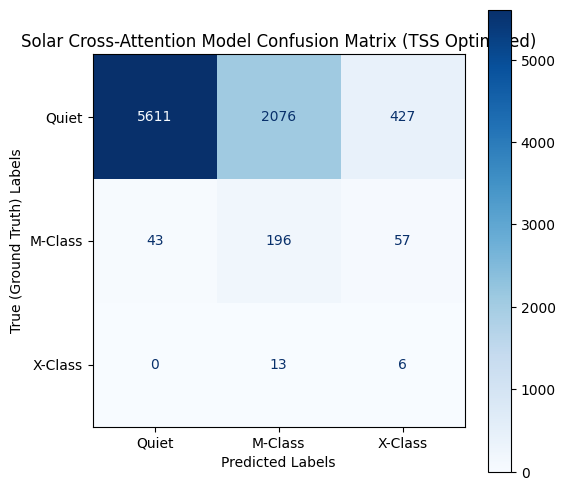

In [ ]:
# This script runs the model for our validation test
# To run this, you need to have the model saved in your drive
# We had an oversight and forgot to put random seed in for training, so if you want to test our model, contact us

# Finds thresholds that maximze tss
def optimize_thresholds(model, dataloader, device):
    model.eval()
    all_probs = []
    all_targets = []

    print("Running TSS threshold sweep to find optimal cutoffs...")
    with torch.no_grad():
        for images, tabular_data, labels in dataloader:
            images = images.to(device)
            tabular_data = tabular_data.to(device).float()
            labels = labels.to(device).long()

            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            # Unpack dual outputs from the two-head model
            binary_logits, severity_logits, _ = model(images, tabular_data)

            # Reconstruct 3-class joint probabilities
            p_binary = torch.softmax(binary_logits, dim=-1)
            p_severity = torch.softmax(severity_logits, dim=-1)
            probabilities = torch.cat([
                p_binary[:, 0:1],                  # P(Quiet)
                p_binary[:, 1:2] * p_severity[:, 0:1], # P(M-Class)
                p_binary[:, 1:2] * p_severity[:, 1:2]  # P(X-Class)
            ], dim=-1)

            all_probs.append(probabilities.cpu().numpy())
            all_targets.append(labels.cpu().numpy())

    y_probs = np.vstack(all_probs)
    y_true = np.concatenate(all_targets)

    thresholds = np.linspace(0.05, 0.95, 91)

    best_m_thresh = 0.20
    best_m_tss = -1.0
    binary_m_true = (y_true == 1).astype(int)

    for thresh in thresholds:
        preds = (y_probs[:, 1] >= thresh).astype(int)
        if preds.sum() == 0 and binary_m_true.sum() > 0:
            continue
        tn, fp, fn, tp = confusion_matrix(binary_m_true, preds, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tss = tpr - fpr
        if tss > best_m_tss:
            best_m_tss = tss
            best_m_thresh = thresh

    best_x_thresh = 0.15
    best_x_tss = -1.0
    binary_x_true = (y_true == 2).astype(int)

    for thresh in thresholds:
        preds = (y_probs[:, 2] >= thresh).astype(int)
        if preds.sum() == 0 and binary_x_true.sum() > 0:
            continue
        tn, fp, fn, tp = confusion_matrix(binary_x_true, preds, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        tss = tpr - fpr
        if tss > best_x_tss:
            best_x_tss = tss
            best_x_thresh = thresh

    print(f"-> Optimal M-Class Threshold: {best_m_thresh:.2f} | Max TSS: {best_m_tss:.4f}")
    print(f"-> Optimal X-Class Threshold: {best_x_thresh:.2f} | Max TSS: {best_x_tss:.4f}\n")

    return float(best_m_thresh), float(best_x_thresh)


# Evaluation & Explainability Extraction Function
def evaluate_and_extract_explainability(model, dataloader, device, x_threshold=0.15, m_threshold=0.20):
    model.eval()
    all_predictions = []
    all_ground_truths = []
    all_attention_maps = []

    with torch.no_grad():
        for images, tabular_data, labels in dataloader:
            images = images.to(device)
            tabular_data = tabular_data.to(device).float()
            labels = labels.to(device).long()

            if images.shape[1] == 1:
                images = images.repeat(1, 3, 1, 1)

            binary_logits, severity_logits, attn_weights = model(images, tabular_data)

            B, query_len, key_sequence_length = attn_weights.shape
            H_prime = int(key_sequence_length**0.5)
            W_prime = key_sequence_length // H_prime

            p_binary = torch.softmax(binary_logits, dim=-1)
            p_severity = torch.softmax(severity_logits, dim=-1)
            probabilities = torch.cat([
                p_binary[:, 0:1],                  # P(Quiet)
                p_binary[:, 1:2] * p_severity[:, 0:1], # P(M-Class)
                p_binary[:, 1:2] * p_severity[:, 1:2]  # P(X-Class)
            ], dim=-1)

            probs_np = probabilities.cpu().numpy()

            predicted_classes = np.zeros(B, dtype=int)
            for i in range(B):
                if probs_np[i, 2] > x_threshold:
                    predicted_classes[i] = 2  # X-Class
                elif probs_np[i, 1] > m_threshold:
                    predicted_classes[i] = 1  # M-Class
                else:
                    predicted_classes[i] = 0  # Quiet (Default)

            all_predictions.extend(predicted_classes)
            all_ground_truths.extend(labels.cpu().numpy())

            spatial_maps = attn_weights.view(B, query_len, H_prime, W_prime).cpu().numpy()
            all_attention_maps.extend(spatial_maps)

    return np.array(all_predictions), np.array(all_ground_truths), np.array(all_attention_maps)


def calculate_metrics_and_tss(all_preds, all_targets):
    cm = confusion_matrix(all_targets, all_preds, labels=[0, 1, 2])

    n_classes = cm.shape[0]
    tpr_per_class = np.zeros(n_classes)
    fpr_per_class = np.zeros(n_classes)
    tss_per_class = np.zeros(n_classes)

    total_samples = cm.sum()

    for i in range(n_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total_samples - (tp + fn + fp)

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

        tpr_per_class[i] = tpr
        fpr_per_class[i] = fpr
        tss_per_class[i] = tpr - fpr

    return cm, tpr_per_class, fpr_per_class, tss_per_class


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_dim = 9
model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8)

# Load checkpoint
model_path = "/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid5_2.pt"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
print("Model state dict successfully loaded from Google Drive!")

optimal_m_thresh, optimal_x_thresh = optimize_thresholds(model, val_loader, device)

predictions, ground_truths, attention_maps = evaluate_and_extract_explainability(
    model=model,
    dataloader=val_loader,
    device=device,
    x_threshold=optimal_x_thresh,
    m_threshold=optimal_m_thresh
)

#Plotting & Metrics Display
cm, tpr, fpr, tss = calculate_metrics_and_tss(predictions, ground_truths)
class_names = ['Quiet', 'M-Class', 'X-Class']

print("\n--- Model Evaluation Summary (Optimized Thresholds) ---")
for i, c_name in enumerate(class_names):
    print(f"{c_name:>8s} | Recall (TPR): {tpr[i]:.4f} | FPR: {fpr[i]:.4f} | TSS: {tss[i]:.4f}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
display.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Solar Cross-Attention Model Confusion Matrix (TSS Optimized)")
plt.xlabel("Predicted Labels")
plt.ylabel("True (Ground Truth) Labels")
plt.show()

Model state dict successfully loaded from Google Drive!
using validation-derived thresholds -> M-Class: {optimal_m_thresh}, X-Class: {optimal_x_thresh}

--- TEST SET Evaluation Summary ---
   Quiet | Recall (TPR): 0.7230 | FPR: 0.1020 | TSS: 0.6211
 M-Class | Recall (TPR): 0.5190 | FPR: 0.2291 | TSS: 0.2899
 X-Class | Recall (TPR): 0.4889 | FPR: 0.0587 | TSS: 0.4302


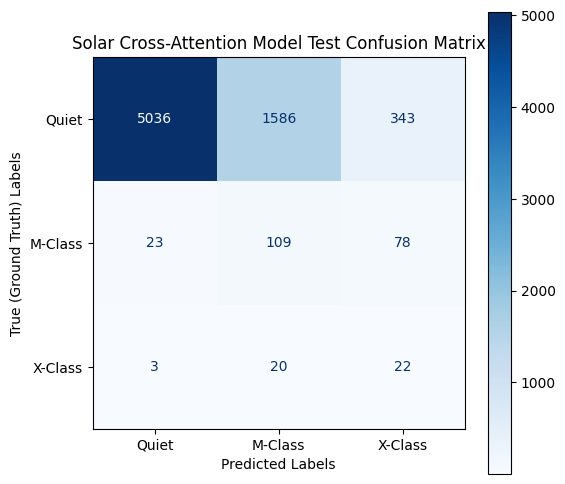

In [ ]:
# This script runs the model through our test set

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_dim = 9
model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8)

model_path = "/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid5_2.pt"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
print("Model state dict successfully loaded from Google Drive!")


print("using validation-derived thresholds -> M-Class: {optimal_m_thresh}, X-Class: {optimal_x_thresh}")

predictions, ground_truths, attention_maps = evaluate_and_extract_explainability(
    model=model,
    dataloader=test_loader,
    device=device,
    x_threshold=optimal_x_thresh,
    m_threshold=optimal_m_thresh
)

cm, tpr, fpr, tss = calculate_metrics_and_tss(predictions, ground_truths)
class_names = ['Quiet', 'M-Class', 'X-Class']

print("\n--- TEST SET Evaluation Summary ---")
for i, c_name in enumerate(class_names):
    print(f"{c_name:>8s} | Recall (TPR): {tpr[i]:.4f} | FPR: {fpr[i]:.4f} | TSS: {tss[i]:.4f}")

display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 6))
display.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Solar Cross-Attention Model Test Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True (Ground Truth) Labels")
plt.show()

In [ ]:
# Gets the 3 scores for our model based on test set

cm = np.array([
    [5036, 1586, 343],   # Actual Quiet
    [23,  109,  78],    # Actual M
    [3,   20,  22]     # Actual X
])

# Collapse M and X into one "Flare" class
TN = cm[0, 0]
FP = cm[0, 1] + cm[0, 2]
FN = cm[1, 0] + cm[2, 0]
TP = cm[1, 1] + cm[1, 2] + cm[2, 1] + cm[2, 2]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

# F1
f1 = (2 * TP) / (2 * TP + FP + FN)

# TSS
tss = (TP / (TP + FN)) - (FP / (FP + TN))

# HSS
hss = (2 * (TP * TN - FP * FN)) / (
    (TP + FN) * (FN + TN) +
    (TP + FP) * (FP + TN)
)

print("F1:", f1)
print("TSS:", tss)
print("HSS:", hss)

TN: 5036
FP: 1929
FN: 26
TP: 229
F1: 0.1898052217157066
TSS: 0.6210830060667483
HSS: 0.13517199631401458


### 3. Explainability

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 90.2MB/s]


Model loaded successfully for explainability testing!
Running full-test set ablation and refined PIL alignment evaluation...
Finished scanning. Total evaluated flare samples: 247


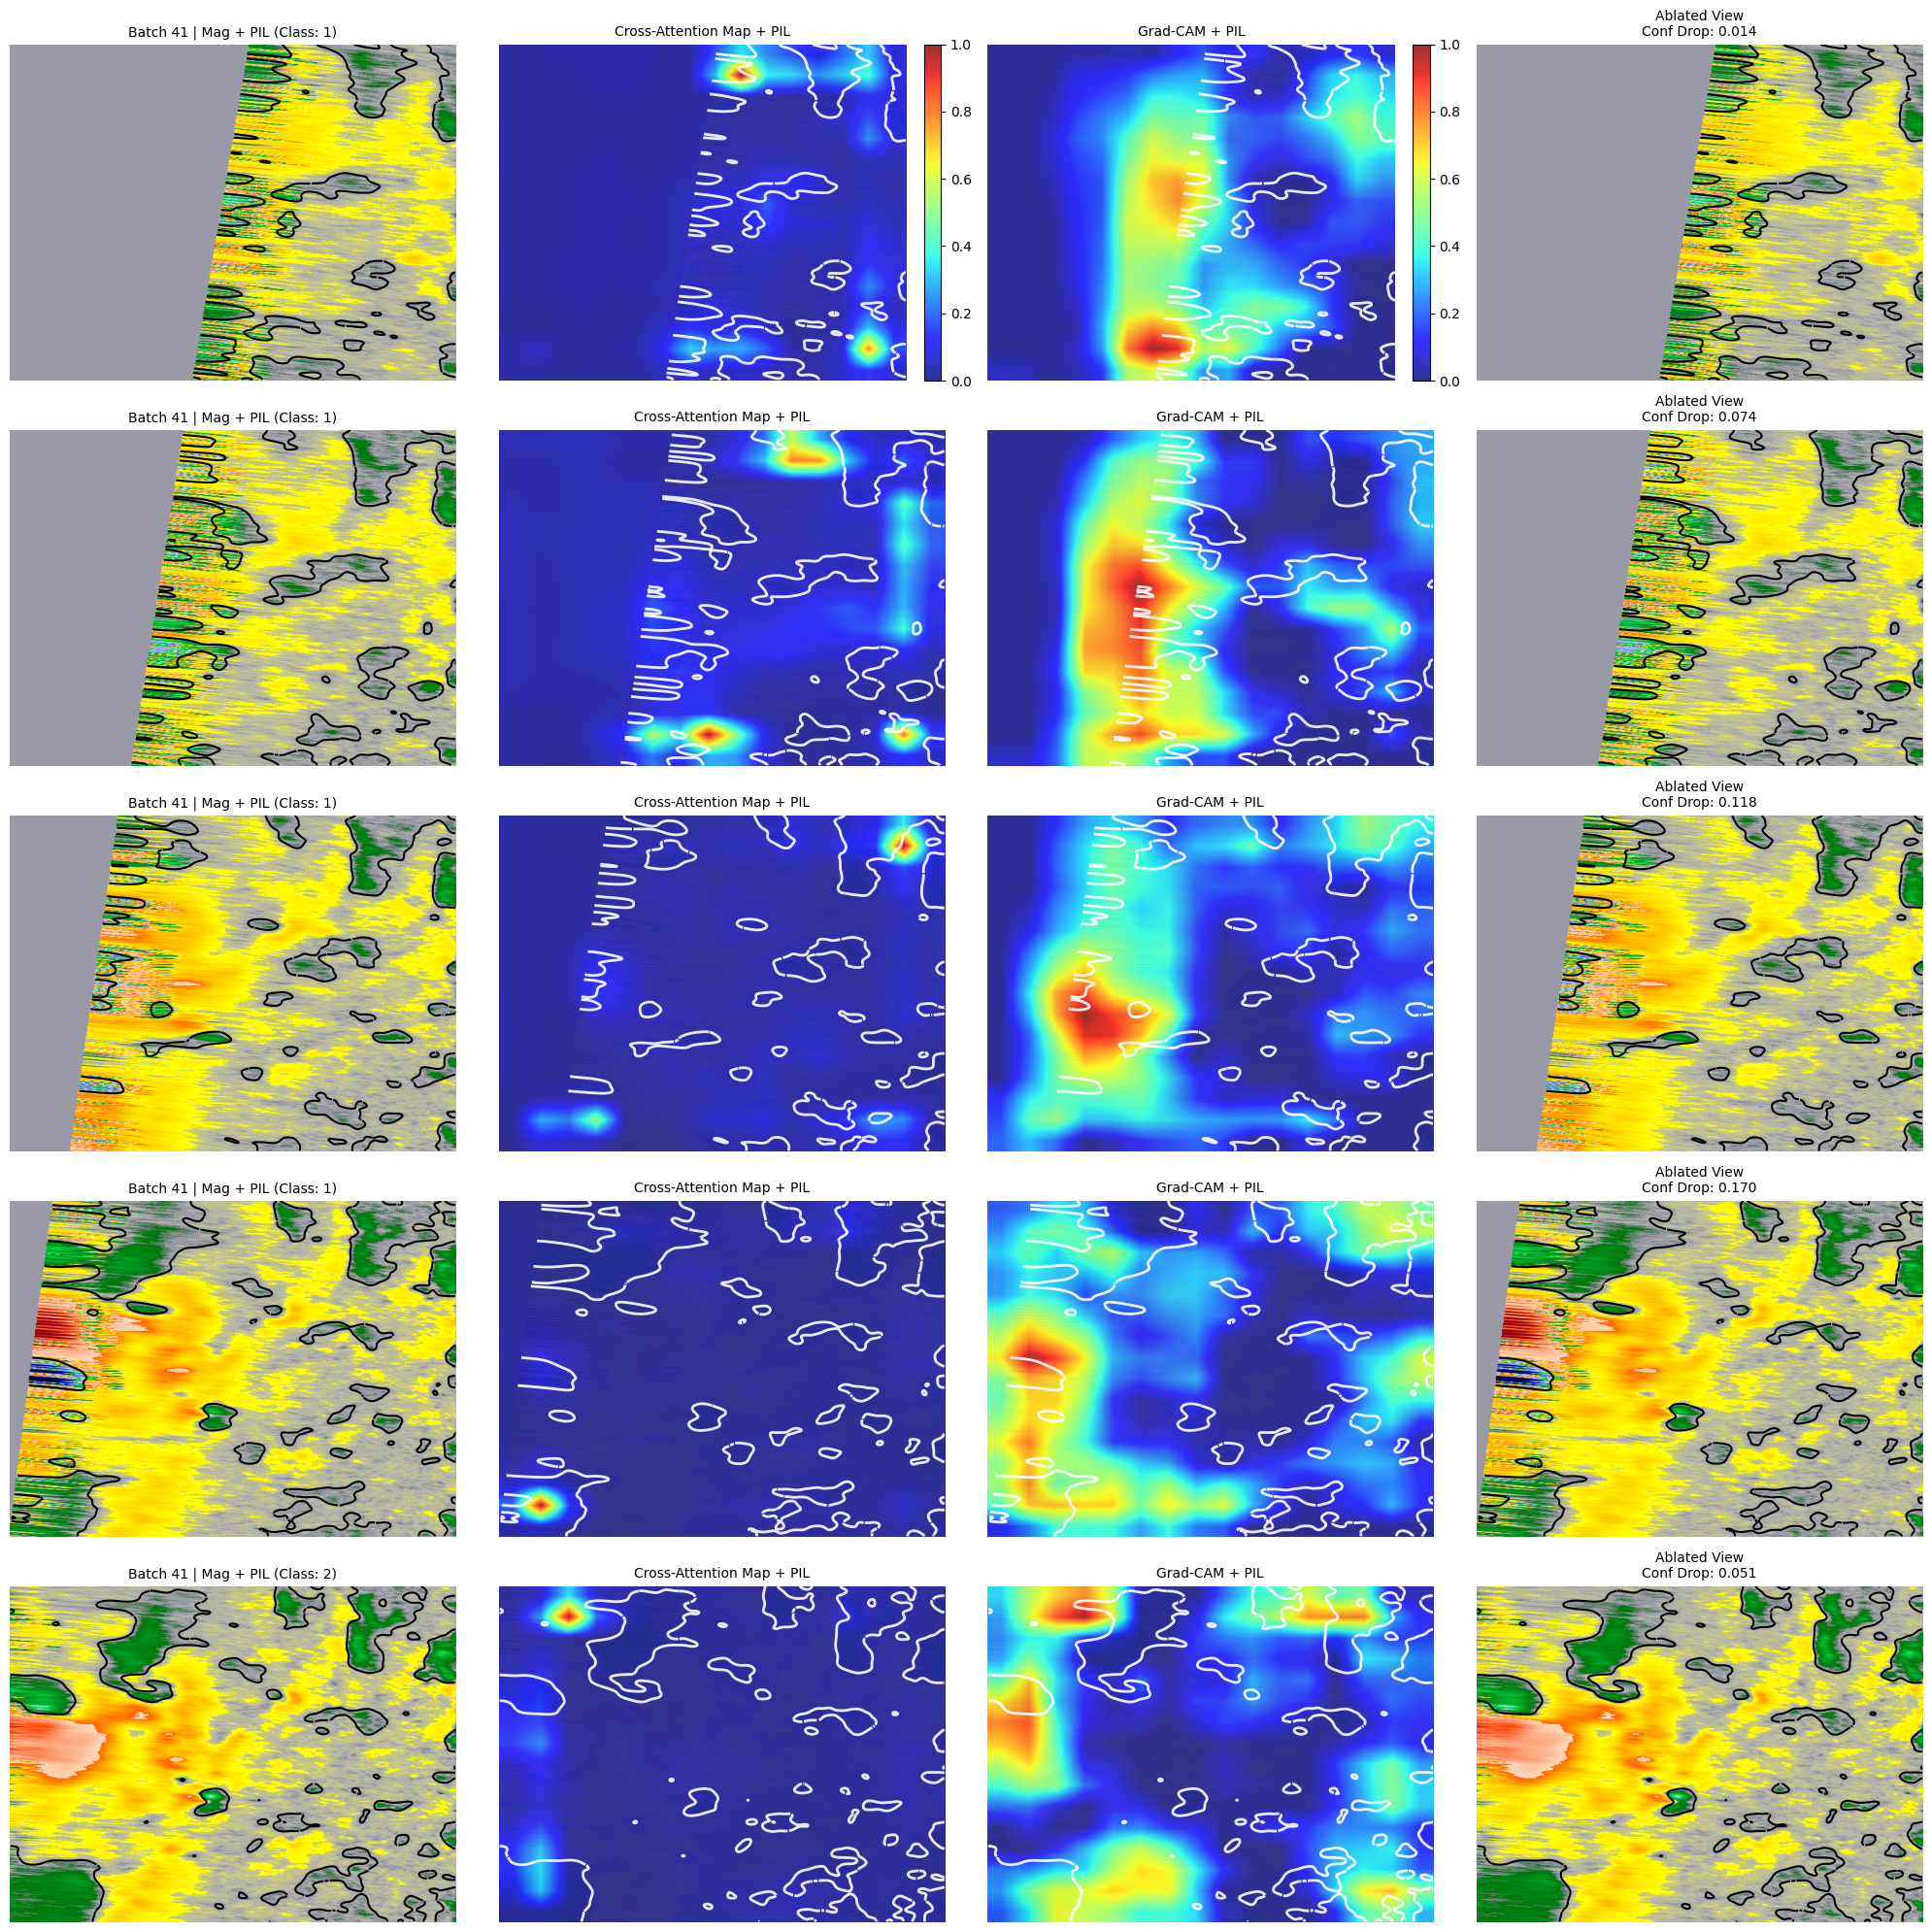


--- Full-Dataset Explainability Metrics ---
Total Evaluated Flare Samples: 247
Robust Average Confidence Drop: -0.0809 (±0.0981)
Mean Attention Mass on PILs (Refined): 0.56% (±0.79%)

--- Generating Scaled SHAP Summary Plot on GPU ---


  0%|          | 0/50 [00:00<?, ?it/s]

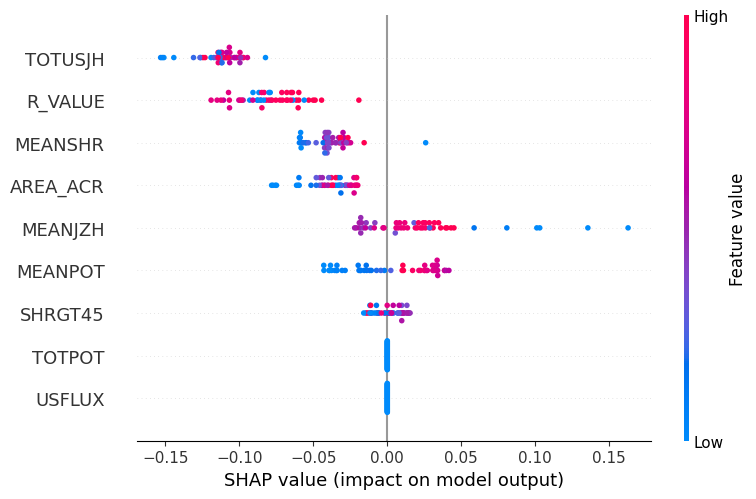

In [ ]:
#This cell generates the Grad-Cam, Attention Map, and SHAP plot for our model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_dim = 9
model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8)

model_path = "/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid5_2.pt"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print("Model loaded successfully for explainability testing!")

# Helper functions
def get_attention_heatmap(attn_weights):
    B, query_len, seq_len = attn_weights.shape
    H_prime = int(seq_len ** 0.5)
    W_prime = seq_len // H_prime

    heatmap = attn_weights.sum(dim=1).cpu().numpy()

    spatial_maps = []
    for i in range(B):
        map_2d = heatmap[i].reshape(H_prime, W_prime)
        map_2d = (map_2d - map_2d.min()) / (map_2d.max() - map_2d.min() + 1e-8)
        spatial_maps.append(map_2d)

    return np.array(spatial_maps)

def compute_gradcam(model, image, tabular_data, target_class=1):
    model.eval()

    activations = None
    gradients = None

    def forward_hook(module, input, output):
        nonlocal activations
        activations = output

    def backward_hook(module, grad_in, grad_out):
        nonlocal gradients
        gradients = grad_out[0]

    target_layer = model.backbone[-1]
    h_fwd = target_layer.register_forward_hook(forward_hook)
    h_bwd = target_layer.register_full_backward_hook(backward_hook)

    H, W = image.shape[1], image.shape[2]

    try:
        with torch.set_grad_enabled(True):
            img_tensor = image.unsqueeze(0).to(device).requires_grad_(True)
            tab_tensor = tabular_data.unsqueeze(0).to(device).float().requires_grad_(True)

            model.zero_grad()
            bin_logits, _, _ = model(img_tensor, tab_tensor)

            if bin_logits.ndim > 1:
                score = bin_logits[0, target_class]
            else:
                score = bin_logits[target_class]

            score.backward()
    except Exception:
        h_fwd.remove()
        h_bwd.remove()
        return np.zeros((H, W), dtype=np.float32)

    h_fwd.remove()
    h_bwd.remove()

    if activations is None or gradients is None or activations.ndim != 4 or gradients.ndim != 4:
        return np.zeros((H, W), dtype=np.float32)

    weights = torch.mean(gradients, dim=[2, 3], keepdim=True)
    cam = torch.sum(weights * activations, dim=1).squeeze(0)
    cam = torch.relu(cam).detach().cpu().numpy()

    if cam.ndim != 2:
        cam = np.squeeze(cam)

    if cam.ndim != 2 or np.isnan(cam).any() or np.isinf(cam).any() or (cam.max() == cam.min()):
        return np.zeros((H, W), dtype=np.float32)

    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam_resized = cv2.resize(cam, (W, H), interpolation=cv2.INTER_LINEAR)
    return cam_resized

def run_ablation_test(model, image, tabular_data, heatmap, device, threshold_percentile=90):
    model.eval()

    with torch.no_grad():
        img_tensor = image.unsqueeze(0).to(device)
        tab_tensor = tabular_data.unsqueeze(0).to(device).float()

        bin_logits, _, _ = model(img_tensor, tab_tensor)
        orig_prob = torch.softmax(bin_logits, dim=-1)[0, 1].item()

    thresh = np.percentile(heatmap, threshold_percentile)
    top_pixels_mask = (heatmap >= thresh).astype(np.uint8)

    orig_img_np = image.cpu().numpy()[0]
    mask_resized = cv2.resize(top_pixels_mask, (orig_img_np.shape[1], orig_img_np.shape[0]), interpolation=cv2.INTER_NEAREST)

    blurred_img = cv2.GaussianBlur(orig_img_np, (15, 15), 0)
    blurred_img[orig_img_np == 0.0] = 0.0

    ablated_img_np = orig_img_np.copy()
    ablated_img_np[mask_resized == 1] = blurred_img[mask_resized == 1]

    ablated_3ch = np.repeat(ablated_img_np[np.newaxis, :, :], 3, axis=0)
    ablated_tensor = torch.tensor(ablated_3ch, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        bin_logits_abl, _, _ = model(ablated_tensor, tab_tensor)
        ablated_prob = torch.softmax(bin_logits_abl, dim=-1)[0, 1].item()

    return orig_prob, ablated_prob, (orig_prob - ablated_prob)


all_drop_results = []
all_pil_fractions = []
collected_rows = []
target_visual_rows = 5

print("Running full-test set ablation and refined PIL alignment evaluation...")

with torch.no_grad():
    for batch_idx, (images, tabular_data, labels) in enumerate(test_loader):
        images = images.to(device)
        tabular_data = tabular_data.to(device).float()
        labels = labels.to(device).long()

        flare_indices = (labels > 0).nonzero(as_tuple=True)[0]
        if len(flare_indices) == 0:
            continue

        _, _, attn_weights = model(images, tabular_data)
        heatmaps = get_attention_heatmap(attn_weights)

        for f_idx in flare_indices:
            i_idx = f_idx.item()
            check_img = images[i_idx].cpu().numpy()[0]

            if np.all(check_img == 0.0) or np.max(check_img) == np.min(check_img):
                continue

            current_img = images[i_idx]
            current_tab = tabular_data[i_idx]
            raw_heatmap = heatmaps[i_idx]

            img_h, img_w = current_img.shape[1], current_img.shape[2]
            current_heatmap = cv2.resize(raw_heatmap, (img_w, img_h), interpolation=cv2.INTER_LINEAR)

            # PIL attention computation
            mag_np_single = current_img.cpu().numpy()[0]
            valid_mask = (mag_np_single != 0.0).astype(np.float32)

            orig_gauss_single = (mag_np_single * 8000.0) - 4000.0
            orig_gauss_single[mag_np_single == 0.0] = 0.0

            smoothed_pil = cv2.GaussianBlur(orig_gauss_single, (25, 25), 0)
            smoothed_pil[valid_mask == 0] = np.nan

            pil_mask = np.isclose(smoothed_pil, 0.0, atol=50.0).astype(np.uint8)

            strong_field_mask = (np.abs(orig_gauss_single) > 200.0).astype(np.uint8)
            refined_pil_mask = pil_mask & strong_field_mask

            kernel = np.ones((3, 3), np.uint8)
            dilated_pil_mask = cv2.dilate(refined_pil_mask, kernel, iterations=1)

            total_attn_mass = np.sum(current_heatmap)
            pil_attn_mass = np.sum(current_heatmap * dilated_pil_mask)
            pil_fraction = pil_attn_mass / (total_attn_mass + 1e-8)
            all_pil_fractions.append(pil_fraction)

            # Run ablation test
            _, _, prob_drop = run_ablation_test(
                model=model,
                image=current_img,
                tabular_data=current_tab,
                heatmap=current_heatmap,
                device=device,
                threshold_percentile=80
            )
            all_drop_results.append(prob_drop)

            # Store first 5 samples for the inspection grid
            if len(collected_rows) < target_visual_rows:
                current_gradcam = compute_gradcam(model, current_img, current_tab, target_class=1)

                img_np = current_img.cpu().numpy()
                if img_np.ndim == 3:
                    img_np = img_np[0]

                orig_gauss_img = (img_np * 8000.0) - 4000.0
                orig_gauss_img[img_np == 0.0] = 0.0

                collected_rows.append({
                    'batch_num': batch_idx + 1,
                    'label': labels[i_idx].item(),
                    'magnetogram': orig_gauss_img,
                    'heatmap': current_heatmap,
                    'gradcam': current_gradcam,
                    'prob_drop': prob_drop,
                    'raw_image': current_img,
                    'raw_tab': current_tab
                })

print(f"Finished scanning. Total evaluated flare samples: {len(all_drop_results)}")

if len(collected_rows) > 0:
    fig, axes = plt.subplots(len(collected_rows), 4, figsize=(20, 4 * len(collected_rows)))

    if len(collected_rows) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, data in enumerate(collected_rows):
        mag_img = data['magnetogram'].copy()

        valid_mask = (mag_img != 0.0).astype(np.float32)
        smoothed_pil = cv2.GaussianBlur(mag_img, (25, 25), 0)
        smoothed_pil[valid_mask == 0] = np.nan

        # Col 1: Magnetogram + PIL
        ax0 = axes[row_idx, 0]
        ax0.imshow(mag_img, cmap='hmimag', vmin=-1500, vmax=1500, origin='lower', aspect='auto')
        ax0.contour(smoothed_pil, levels=[0], colors='black', linewidths=1.5, origin='lower')
        ax0.set_title(f"Batch {data['batch_num']} | Mag + PIL (Class: {data['label']})", fontsize=10)
        ax0.axis('off')

        # Col 2: Cross-Attention Map + PIL
        ax1 = axes[row_idx, 1]
        ax1.imshow(mag_img, cmap='hmimag', vmin=-1500, vmax=1500, origin='lower', aspect='auto', alpha=0.3)
        im1 = ax1.imshow(data['heatmap'], cmap='jet', vmin=0.0, vmax=1.0, alpha=0.8, interpolation='bilinear', origin='lower', aspect='auto')
        ax1.contour(smoothed_pil, levels=[0], colors='white', linewidths=2.0, origin='lower', alpha=0.9)
        ax1.set_title("Cross-Attention Map + PIL", fontsize=10)
        ax1.axis('off')
        if row_idx == 0:
            fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

        # Col 3: Grad-CAM Map + PIL
        ax2 = axes[row_idx, 2]
        ax2.imshow(mag_img, cmap='hmimag', vmin=-1500, vmax=1500, origin='lower', aspect='auto', alpha=0.3)
        im2 = ax2.imshow(data['gradcam'], cmap='jet', vmin=0.0, vmax=1.0, alpha=0.8, interpolation='bilinear', origin='lower', aspect='auto')
        ax2.contour(smoothed_pil, levels=[0], colors='white', linewidths=2.0, origin='lower', alpha=0.9)
        ax2.set_title("Grad-CAM + PIL", fontsize=10)
        ax2.axis('off')
        if row_idx == 0:
            fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

        # Col 4: Ablated View + PIL
        ax3 = axes[row_idx, 3]
        ax3.imshow(mag_img, cmap='hmimag', vmin=-1500, vmax=1500, origin='lower', aspect='auto')
        ax3.contour(smoothed_pil, levels=[0], colors='black', linewidths=1.5, origin='lower')
        ax3.set_title(f"Ablated View\nConf Drop: {data['prob_drop']:.3f}", fontsize=10)
        ax3.axis('off')

    plt.tight_layout()
    plt.show()

print(f"\n--- Full-Dataset Explainability Metrics ---")
if len(all_drop_results) > 0:
    mean_drop = np.mean(all_drop_results)
    std_drop = np.std(all_drop_results)
    print(f"Total Evaluated Flare Samples: {len(all_drop_results)}")
    print(f"Robust Average Confidence Drop: {mean_drop:.4f} (±{std_drop:.4f})")

if len(all_pil_fractions) > 0:
    mean_pil_frac = np.mean(all_pil_fractions) * 100.0
    std_pil_frac = np.std(all_pil_fractions) * 100.0
    print(f"Mean Attention Mass on PILs (Refined): {mean_pil_frac:.2f}% (±{std_pil_frac:.2f}%)")


print("\n--- Generating Scaled SHAP Summary Plot on GPU ---")

background_tabs = []
evaluation_tabs = []

max_bg = 30
max_eval = 50

with torch.no_grad():
    for images, tabular_data, labels in test_loader:
        for i in range(images.size(0)):
            if labels[i] > 0 and len(background_tabs) < max_bg:
                background_tabs.append(tabular_data[i].cpu().numpy())
            elif len(evaluation_tabs) < max_eval:
                evaluation_tabs.append(tabular_data[i].cpu().numpy())
            if len(background_tabs) >= max_bg and len(evaluation_tabs) >= max_eval:
                break
        if len(background_tabs) >= max_bg and len(evaluation_tabs) >= max_eval:
            break

background_tabs = np.array(background_tabs)
evaluation_tabs = np.array(evaluation_tabs)

fixed_img_tensor = collected_rows[0]['raw_image'].unsqueeze(0).to(device)

def model_predict_wrapper(tab_np):
    model.to(device)
    model.eval()

    preds = []
    chunk_size = 64

    for i in range(0, tab_np.shape[0], chunk_size):
        tab_chunk = torch.tensor(tab_np[i:i+chunk_size], dtype=torch.float32).to(device)
        curr_batch_size = tab_chunk.shape[0]
        img_chunk = fixed_img_tensor.repeat(curr_batch_size, 1, 1, 1)

        with torch.no_grad():
            bin_logits, _, _ = model(img_chunk, tab_chunk)
            probs = torch.softmax(bin_logits, dim=-1)
            preds.append(probs[:, 1].cpu().numpy())

    return np.concatenate(preds, axis=0)

explainer = shap.KernelExplainer(model_predict_wrapper, background_tabs)
shap_values = explainer.shap_values(evaluation_tabs)

param_names = [
    "USFLUX",
    "TOTUSJH",
    "TOTPOT",
    "MEANSHR",
    "MEANJZH",
    "R_VALUE",
    "AREA_ACR",
    "SHRGT45",
    "MEANPOT"
]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, evaluation_tabs, feature_names=param_names, show=True)

In [ ]:
# This model does our first modality ablation testing, where the entire spatial data is removed and the model is only trained on tabular data.

model.eval()
real_probs = []
zero_probs = []

print("Running Zero-Image Diagnostic Comparison...")

with torch.no_grad():
    for images, tabular_data, labels in test_loader:
        images = images.to(device)
        tabular_data = tabular_data.to(device).float()

        flare_mask = (labels > 0)
        if not flare_mask.any():
            continue

        images_flare = images[flare_mask]
        tab_flare = tabular_data[flare_mask]

        logits_real, _, _ = model(images_flare, tab_flare)
        probs_real = torch.softmax(logits_real, dim=-1)[:, 1]
        real_probs.extend(probs_real.cpu().numpy())

        zero_images = torch.zeros_like(images_flare)
        logits_zero, _, _ = model(zero_images, tab_flare)
        probs_zero = torch.softmax(logits_zero, dim=-1)[:, 1]
        zero_probs.extend(probs_zero.cpu().numpy())

mean_real = np.mean(real_probs)
mean_zero = np.mean(zero_probs)

print(f"\n--- Zero-Image Test Results ---")
print(f"Mean Flare Probability (Real Images): {mean_real:.4f}")
print(f"Mean Flare Probability (Zero Images): {mean_zero:.4f}")
print(f"Absolute Difference: {abs(mean_real - mean_zero):.4f}")

Running Zero-Image Diagnostic Comparison...

--- Zero-Image Test Results ---
Mean Flare Probability (Real Images): 0.6259
Mean Flare Probability (Zero Images): 0.5611
Absolute Difference: 0.0648


In [ ]:
# This cell does our second modality ablation testing, where tabular data is removed and the model only trains on spatial data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tabular_dim = 9
model = SolarCrossAttention(tabular_dim=tabular_dim, embed_dim=512, num_heads=8)

model_path = "/content/drive/MyDrive/SolarFlareNet_Final_Locked_Splits/checkpoint_epochV4_hybrid5_2.pt"
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)

model.eval()
real_probs = []
zero_tab_probs = []

print("Running Zero-Tabular Diagnostic Comparison...")

with torch.no_grad():
    for images, tabular_data, labels in test_loader:
        images = images.to(device)
        tabular_data = tabular_data.to(device).float()

        flare_mask = (labels > 0)
        if not flare_mask.any():
            continue

        images_flare = images[flare_mask]
        tab_flare = tabular_data[flare_mask]

        logits_real, _, _ = model(images_flare, tab_flare)
        probs_real = torch.softmax(logits_real, dim=-1)[:, 1]
        real_probs.extend(probs_real.cpu().numpy())

        zero_tabular = torch.zeros_like(tab_flare)
        logits_zero_tab, _, _ = model(images_flare, zero_tabular)
        probs_zero_tab = torch.softmax(logits_zero_tab, dim=-1)[:, 1]
        zero_tab_probs.extend(probs_zero_tab.cpu().numpy())

mean_real = np.mean(real_probs)
mean_zero_tab = np.mean(zero_tab_probs)

print(f"\n--- Zero-Tabular Test Results ---")
print(f"Mean Flare Probability (Real Data): {mean_real:.4f}")
print(f"Mean Flare Probability (Zero Tabular): {mean_zero_tab:.4f}")
print(f"Absolute Difference: {abs(mean_real - mean_zero_tab):.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Running Zero-Tabular Diagnostic Comparison...

--- Zero-Tabular Test Results ---
Mean Flare Probability (Real Data): 0.6259
Mean Flare Probability (Zero Tabular): 0.2575
Absolute Difference: 0.3684
